# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



In [ ]:
import numpy as np
import pandas as pd


class MyBinaryLogisticRegression:
    """
    Бинарная логистическая регрессия.

    penalty:
        'none'  - без регуляризации
        'l2'    - L2
        'l1'    - L1 (через proximal шаг)
        'l1l2'  - ElasticNet (L2 в градиенте, L1 через proximal шаг)

    method:
        'gd'     - градиентный спуск
        'sgd'    - стохастический градиентный спуск (minibatch)
        'newton' - метод Ньютона (только для smooth: 'none'/'l2')
    """

    def __init__(
        self,
        method="gd",
        penalty="l2",
        C=1.0,
        l1_ratio=0.5,
        fit_intercept=True,
        reg_intercept=False,
        lr=0.1,
        max_iter=1000,
        tol=1e-6,
        batch_size=32,
        random_state=42,
        verbose=0,
    ):
        self.method = method
        self.penalty = penalty
        self.C = float(C)
        self.l1_ratio = float(l1_ratio)

        self.fit_intercept = bool(fit_intercept)
        self.reg_intercept = bool(reg_intercept)

        self.lr = float(lr)
        self.max_iter = int(max_iter)
        self.tol = float(tol)

        self.batch_size = int(batch_size)
        self.random_state = random_state
        self.verbose = int(verbose)

        self.coefs_ = None
        self.feature_names_in_ = None

    def _sigmoid(self, z):
        z = np.clip(z, -35, 35)
        return 1.0 / (1.0 + np.exp(-z))

    def _add_intercept(self, X):
        if not self.fit_intercept:
            return X
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def _lambda(self):
        if self.penalty == "none":
            return 0.0
        return 1.0 / self.C

    def _soft_threshold(self, w, t):
        return np.sign(w) * np.maximum(np.abs(w) - t, 0.0)

    def _prepare_xy(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = np.array(X.columns, dtype=object)
            Xn = X.values.astype(float)
        else:
            Xn = np.asarray(X, dtype=float)

        if y is None:
            return Xn, None

        if isinstance(y, (pd.Series, pd.DataFrame)):
            yn = np.asarray(y).reshape(-1).astype(float)
        else:
            yn = np.asarray(y).reshape(-1).astype(float)

        # {-1,1} -> {0,1} если нужно
        uniq = set(np.unique(yn).tolist())
        if uniq == {-1.0, 1.0}:
            yn = (yn == 1.0).astype(float)

        return Xn, yn

    def _loss_grad(self, Xb, y, w):
        n = Xb.shape[0]
        p = self._sigmoid(Xb @ w)

        eps = 1e-12
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        grad = (Xb.T @ (p - y)) / n

        lam = self._lambda()
        if lam == 0.0:
            return loss, grad

        w_reg = w.copy()
        if self.fit_intercept and (not self.reg_intercept):
            w_reg[0] = 0.0

        if self.penalty == "l2":
            loss += 0.5 * lam * np.sum(w_reg ** 2)
            grad += lam * w_reg
            return loss, grad

        if self.penalty == "l1":
            loss += lam * np.sum(np.abs(w_reg))
            sub = np.sign(w_reg)
            sub[w_reg == 0.0] = 0.0
            grad += lam * sub
            return loss, grad

        if self.penalty == "l1l2":
            r = self.l1_ratio
            loss += lam * (r * np.sum(np.abs(w_reg)) + (1 - r) * 0.5 * np.sum(w_reg ** 2))
            sub = np.sign(w_reg)
            sub[w_reg == 0.0] = 0.0
            grad += lam * (r * sub + (1 - r) * w_reg)
            return loss, grad

        raise ValueError("Unknown penalty")

    def _hessian_l2(self, Xb, w):
        n = Xb.shape[0]
        p = self._sigmoid(Xb @ w)
        s = p * (1 - p)
        H = (Xb * s[:, None]).T @ Xb / n

        lam = self._lambda()
        if self.penalty == "l2" and lam != 0.0:
            R = np.eye(Xb.shape[1])
            if self.fit_intercept and (not self.reg_intercept):
                R[0, 0] = 0.0
            H = H + lam * R
        return H

    def _prox_after_step(self, w):
        """
        Prox шаг для L1 части. Для L2 ничего не делаем (она уже в градиенте).
        """
        lam = self._lambda()
        if lam == 0.0:
            return w

        if self.penalty == "l1":
            t = self.lr * lam
            if self.fit_intercept and (not self.reg_intercept):
                w[1:] = self._soft_threshold(w[1:], t)
            else:
                w = self._soft_threshold(w, t)
            return w

        if self.penalty == "l1l2":
            t = self.lr * lam * self.l1_ratio
            if t == 0.0:
                return w
            if self.fit_intercept and (not self.reg_intercept):
                w[1:] = self._soft_threshold(w[1:], t)
            else:
                w = self._soft_threshold(w, t)
            return w

        return w

    def _fit_gd(self, Xb, y):
        w = np.zeros(Xb.shape[1])
        prev = np.inf

        lam = self._lambda()
        r = self.l1_ratio

        for it in range(self.max_iter):
            if self.penalty == "l1l2":
                # градиент гладкой части: logloss + L2
                n = Xb.shape[0]
                p = self._sigmoid(Xb @ w)
                grad_log = (Xb.T @ (p - y)) / n

                w_reg = w.copy()
                if self.fit_intercept and (not self.reg_intercept):
                    w_reg[0] = 0.0

                grad_smooth = grad_log + lam * (1 - r) * w_reg
                w = w - self.lr * grad_smooth
                w = self._prox_after_step(w)
                loss, _ = self._loss_grad(Xb, y, w)
            else:
                loss, grad = self._loss_grad(Xb, y, w)
                w = w - self.lr * grad
                w = self._prox_after_step(w)

            if self.verbose and (it % 100 == 0):
                print(f"iter={it}, loss={loss:.6f}")

            if abs(prev - loss) < self.tol:
                break
            prev = loss

        return w

    def _fit_sgd(self, Xb, y):
        rng = np.random.default_rng(self.random_state)
        w = np.zeros(Xb.shape[1])
        prev = np.inf

        n = Xb.shape[0]
        bs = min(max(1, self.batch_size), n)

        lam = self._lambda()
        r = self.l1_ratio

        for it in range(self.max_iter):
            idx = rng.choice(n, size=bs, replace=False)
            Xs = Xb[idx]
            ys = y[idx]

            if self.penalty == "l1l2":
                p = self._sigmoid(Xs @ w)
                grad_log = (Xs.T @ (p - ys)) / bs

                w_reg = w.copy()
                if self.fit_intercept and (not self.reg_intercept):
                    w_reg[0] = 0.0

                grad_smooth = grad_log + lam * (1 - r) * w_reg
                w = w - self.lr * grad_smooth
                w = self._prox_after_step(w)
            else:
                _, grad = self._loss_grad(Xs, ys, w)
                w = w - self.lr * grad
                w = self._prox_after_step(w)

            if it % 20 == 0:
                loss, _ = self._loss_grad(Xb, y, w)
                if self.verbose and (it % 100 == 0):
                    print(f"iter={it}, loss={loss:.6f}")
                if abs(prev - loss) < self.tol:
                    break
                prev = loss

        return w

    def _fit_newton(self, Xb, y):
        if self.penalty not in ("none", "l2"):
            raise ValueError("Newton применим только для penalty='none' или 'l2' (нужна гладкость).")

        w = np.zeros(Xb.shape[1])
        prev = np.inf

        for it in range(self.max_iter):
            loss, grad = self._loss_grad(Xb, y, w)
            H = self._hessian_l2(Xb, w)

            try:
                step = np.linalg.solve(H, grad)
            except np.linalg.LinAlgError:
                step = np.linalg.solve(H + 1e-6 * np.eye(H.shape[0]), grad)

            t = 1.0
            w_new = w - t * step
            for _ in range(20):
                new_loss, _ = self._loss_grad(Xb, y, w_new)
                if new_loss <= loss:
                    break
                t *= 0.5
                w_new = w - t * step

            w = w_new

            if self.verbose and (it % 10 == 0):
                print(f"iter={it}, loss={loss:.6f}")

            if abs(prev - loss) < self.tol:
                break
            prev = loss

        return w

    def fit(self, X: pd.DataFrame, y):
        Xn, yn = self._prepare_xy(X, y)
        Xb = self._add_intercept(Xn)

        if self.method == "gd":
            self.coefs_ = self._fit_gd(Xb, yn)
        elif self.method == "sgd":
            self.coefs_ = self._fit_sgd(Xb, yn)
        elif self.method == "newton":
            self.coefs_ = self._fit_newton(Xb, yn)
        else:
            raise ValueError("method должен быть 'gd', 'sgd' или 'newton'")

        return self

    def predict_proba(self, X):
        Xn, _ = self._prepare_xy(X, None)
        Xb = self._add_intercept(Xn)
        p1 = self._sigmoid(Xb @ self.coefs_)
        return np.vstack([1 - p1, p1]).T

    def predict(self, X):
        p = self.predict_proba(X)[:, 1]
        return (p >= 0.5).astype(int)

    def score(self, X, y):
        Xn, yn = self._prepare_xy(X, y)
        yp = self.predict(Xn)
        return float(np.mean(yp == yn))

Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving penguins_binary_classification.csv to penguins_binary_classification (1).csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['penguins_binary_classification.csv']))

In [ ]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            274 non-null    object 
 1   island             274 non-null    object 
 2   bill_length_mm     274 non-null    float64
 3   bill_depth_mm      274 non-null    float64
 4   flipper_length_mm  274 non-null    float64
 5   body_mass_g        274 non-null    float64
 6   year               274 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 15.1+ KB


Зададим признаки

In [ ]:
df["target"] = (df["species"] == "Adelie").astype(int)

num_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "year",
]

cat_feature = "island"

X_num = df[num_features]
X_cat = df[[cat_feature]]
y = df["target"]

Разделим на тестовую и обучающую

In [ ]:
X_num_train, X_num_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_num, X_cat, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Target Encoding

In [ ]:
global_mean = y_train.mean()

island_target_mean = (
    pd.DataFrame({"island": X_cat_train["island"], "y": y_train})
    .groupby("island")["y"]
    .mean()
)

X_cat_train_te = X_cat_train["island"].map(island_target_mean).fillna(global_mean)
X_cat_test_te = X_cat_test["island"].map(island_target_mean).fillna(global_mean)

X_train_te = pd.concat(
    [X_num_train.reset_index(drop=True),
     X_cat_train_te.reset_index(drop=True)],
    axis=1
)

X_test_te = pd.concat(
    [X_num_test.reset_index(drop=True),
     X_cat_test_te.reset_index(drop=True)],
    axis=1
)

One-hot Encoding

In [ ]:
ohe = OneHotEncoder(sparse_output=False, drop="first")

X_cat_train_ohe = ohe.fit_transform(X_cat_train)
X_cat_test_ohe = ohe.transform(X_cat_test)

X_train_ohe = np.hstack([X_num_train.values, X_cat_train_ohe])
X_test_ohe = np.hstack([X_num_test.values, X_cat_test_ohe])

Реализуем написанный ранее класс

In [ ]:
penalties = ["none", "l1", "l2", "l1l2"]
methods = ["gd", "sgd", "newton"]

datasets = {
    "target_encoding": (X_train_te, X_test_te),
    "one_hot": (X_train_ohe, X_test_ohe),
}

results = []

for enc_name, (Xtr, Xte) in datasets.items():
    for penalty in penalties:
        for method in methods:

            # Метод Ньютона применим только для гладких штрафов
            if method == "newton" and penalty in ("l1", "l1l2"):
                continue

            model = MyBinaryLogisticRegression(
                method=method,
                penalty=penalty,
                C=1.0,
                l1_ratio=0.5,
                lr=0.1,
                max_iter=2000,
                tol=1e-6,
                batch_size=32,
                random_state=42,
                verbose=0
            )

            model.fit(Xtr, y_train)
            y_pred = model.predict(Xte)

            f1 = f1_score(y_test, y_pred)

            results.append({
                "encoding": enc_name,
                "penalty": penalty,
                "method": method,
                "f1_score": f1
            })

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)


Посмотрим на результаты:

In [ ]:
results_df

,encoding,penalty,method,f1_score
2,target_encoding,none,newton,1.000000
12,one_hot,none,newton,1.000000
7,target_encoding,l2,newton,0.972973
17,one_hot,l2,newton,0.972973
3,target_encoding,l1,gd,0.918919
13,one_hot,l1,gd,0.918919
10,one_hot,none,gd,0.909091
0,target_encoding,none,gd,0.909091
4,target_encoding,l1,sgd,0.878049
14,one_hot,l1,sgd,0.878049


Лучший результат для каждого из encoding:

In [ ]:
best_by_encoding = results_df.sort_values("f1_score", ascending=False).groupby("encoding").head(1)
best_by_encoding

,encoding,penalty,method,f1_score
2,target_encoding,none,newton,1.0
12,one_hot,none,newton,1.0


Сводная таблица (mean f1 по комбинациям)

In [ ]:
summary_df = results_df.pivot_table(
    index=["encoding", "penalty"],
    columns="method",
    values="f1_score",
    aggfunc="mean"
)

summary_df

method                         gd    newton       sgd
encoding        penalty                              
one_hot         l1       0.918919       NaN  0.878049
                l1l2     0.710280       NaN  0.000000
                l2       0.710280  0.972973  0.000000
                none     0.909091  1.000000  0.000000
target_encoding l1       0.918919       NaN  0.878049
                l1l2     0.710280       NaN  0.000000
                l2       0.710280  0.972973  0.000000
                none     0.909091  1.000000  0.000000

# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

## Многоклассовая логистическая регрессия (softmax): функция потерь, градиент и гессиан

Обозначения:
$$
X\in\mathbb R^{N\times d},\quad W\in\mathbb R^{d\times M},\quad Z=XW\in\mathbb R^{N\times M},
$$
$$
z_{ij}=(XW)_{ij}=\omega_j^\top x_i.
$$

Обозначим $P\in\mathbb R^{N\times M}$, $P_{ij}=p_{ij}$, и $Y\in\mathbb R^{N\times M}$, $Y_{ij}=y_{ij}$.


### Правдоподобие и функция потерь

Лог-правдоподобие:

$$
\log\mathbb P(D\mid W)=\sum_{i=1}^N\sum_{j=1}^M y_{ij}\log p_{ij}.
$$

Функция потерь:

$$
\mathcal L(W)=-\sum_{i=1}^N\sum_{j=1}^M y_{ij}\log p_{ij}.
$$

Так как

$$
\log p_{ij}=\log\left(\frac{e^{z_{ij}}}{\sum_{k=1}^M e^{z_{ik}}}\right)
=z_{ij}-\log\left(\sum_{k=1}^M e^{z_{ik}}\right),
$$

то

$$
\mathcal L(W)
=-\sum_{i=1}^N\sum_{j=1}^M y_{ij}z_{ij}
+\sum_{i=1}^N\left(\sum_{j=1}^M y_{ij}\right)\log\left(\sum_{k=1}^M e^{z_{ik}}\right).
$$

Поскольку $\sum_{j=1}^M y_{ij}=1$, получаем

$$
\mathcal L(W)
=-\sum_{i=1}^N\sum_{j=1}^M y_{ij}z_{ij}
+\sum_{i=1}^N \log\left(\sum_{k=1}^M e^{z_{ik}}\right)
\qquad Z=XW.
$$


### Производная по $Z$: $\frac{\partial\mathcal L}{\partial Z}$

Рассмотрим вклад одного объекта:

$$
\ell_i = -\sum_{j=1}^M y_{ij}\log p_{ij}.
$$

Используя разложение выше:
$$
\ell_i = -\sum_{j=1}^M y_{ij}z_{ij} + \log\left(\sum_{k=1}^M e^{z_{ik}}\right).
$$

Берём производную по $z_{im}$:

$$
\frac{\partial \ell_i}{\partial z_{im}}
= -y_{im} + \frac{1}{\sum_{k=1}^M e^{z_{ik}}}\cdot e^{z_{im}}
= -y_{im} + p_{im}.
$$

Следовательно,

$$
\frac{\partial \mathcal L}{\partial Z_{im}} = p_{im}-y_{im}
\qquad\Rightarrow\qquad
\frac{\partial \mathcal L}{\partial Z}=P-Y
$$



### Градиент по параметрам $W$

По правилу цепочки:

$$
\frac{\partial \mathcal L}{\partial W_{am}}
=
\sum_{i=1}^N\sum_{j=1}^M
\frac{\partial \mathcal L}{\partial Z_{ij}}
\frac{\partial Z_{ij}}{\partial W_{am}}.
$$

Так как

$$
Z_{ij}=\sum_{b=1}^d X_{ib}W_{bj},
\qquad\Rightarrow\qquad
\frac{\partial Z_{ij}}{\partial W_{am}}=X_{ia}\,\delta_{jm},
$$

то

$$
\frac{\partial \mathcal L}{\partial W_{am}}
=
\sum_{i=1}^N\sum_{j=1}^M
(P-Y)_{ij}\,X_{ia}\,\delta_{jm}
=
\sum_{i=1}^N X_{ia}(P-Y)_{im}.
$$

Это и есть элемент $(a,m)$ произведения $X^\top(P-Y)$, поэтому

$$
\nabla_W \mathcal L(W)=X^\top(P-Y)
$$


### Гессиан по $W$

Гессиан определяется как

$$
H_{(am),(bn)}=\frac{\partial^2 \mathcal L}{\partial W_{am}\,\partial W_{bn}}.
$$

Из градиента:

$$
\frac{\partial \mathcal L}{\partial W_{am}}=\sum_{i=1}^N X_{ia}(P_{im}-Y_{im}),
$$

получаем

$$
\frac{\partial^2 \mathcal L}{\partial W_{am}\partial W_{bn}}
=
\sum_{i=1}^N X_{ia}\frac{\partial P_{im}}{\partial W_{bn}}.
$$

Найдём $\frac{\partial P_{im}}{\partial W_{bn}}$ через цепочку $W\to Z\to P$:

$$
\frac{\partial P_{im}}{\partial W_{bn}}
=\sum_{j=1}^M \frac{\partial P_{im}}{\partial Z_{ij}}\frac{\partial Z_{ij}}{\partial W_{bn}}.
$$

**Производная softmax по $Z$.**
Для фиксированного $i$:
$$
P_{im}=\frac{e^{Z_{im}}}{\sum_{k=1}^M e^{Z_{ik}}}.
$$
Тогда
$$
\frac{\partial P_{im}}{\partial Z_{ij}}
=
P_{im}(\delta_{mj}-P_{ij})
$$

**Производная $Z$ по параметрам.**

$$
\frac{\partial Z_{ij}}{\partial W_{bn}}=X_{ib}\delta_{jn}.
$$

Следовательно,

$$
\frac{\partial P_{im}}{\partial W_{bn}}
=
\sum_{j=1}^M P_{im}(\delta_{mj}-P_{ij})\,X_{ib}\delta_{jn}
=
P_{im}(\delta_{mn}-P_{in})X_{ib}.
$$

Подставляя в гессиан:

$$
\frac{\partial^2 \mathcal L}{\partial W_{am}\partial W_{bn}}
=
\sum_{i=1}^N X_{ia}X_{ib}\,P_{im}(\delta_{mn}-P_{in})
$$

### Блочно-матричная форма гессиана

Рассмотрим гессиан как блочную матрицу $H$ из блоков $H_{mn}\in\mathbb R^{d\times d}$, где

$$
(H_{mn})_{ab}=\frac{\partial^2 \mathcal L}{\partial W_{am}\partial W_{bn}}.
$$

Введём диагональные матрицы $R_{mn}\in\mathbb R^{N\times N}$:

$$
(R_{mn})_{ii}=P_{im}(\delta_{mn}-P_{in}).
$$

Тогда

$$
H_{mn}=X^\top R_{mn}X
$$

В частности:

$$
(R_{mm})_{ii}=P_{im}(1-P_{im}),\qquad
(R_{mn})_{ii}=-P_{im}P_{in}\ \ (m\neq n).
$$

### Компактная форма через якобиан softmax и кронекер

Для каждого $i$ обозначим $p_i\in\mathbb R^M$ — строку вероятностей.
Якобиан softmax:

$$
J_i=\mathrm{diag}(p_i)-p_ip_i^\top.
$$

Тогда гессиан:

$$
\nabla_W^2\mathcal L
=
\sum_{i=1}^N (x_ix_i^\top)\otimes J_i
$$

### Синтетический пример

Сделаем 4 класса в двумерном пространстве

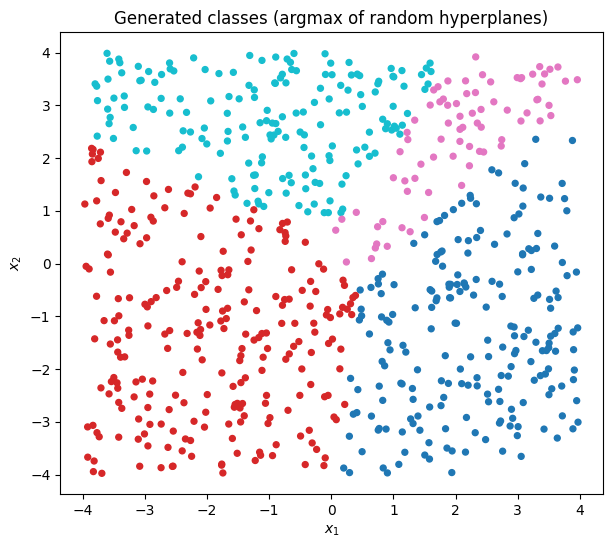

Final loss: 0.1221
Train accuracy: 0.987


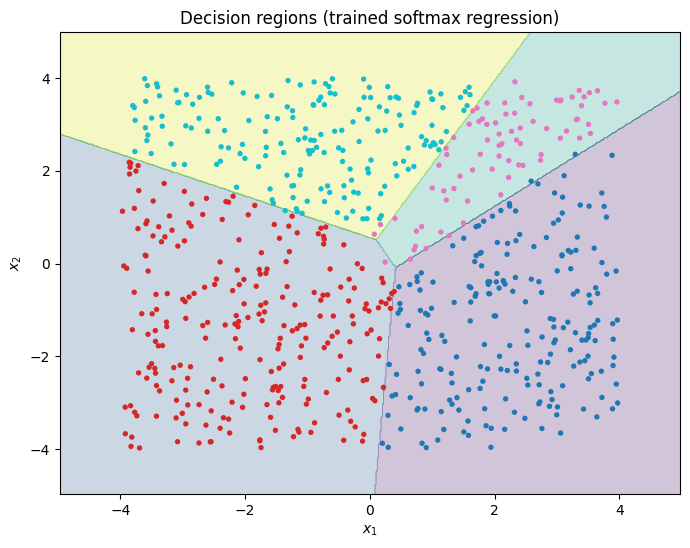

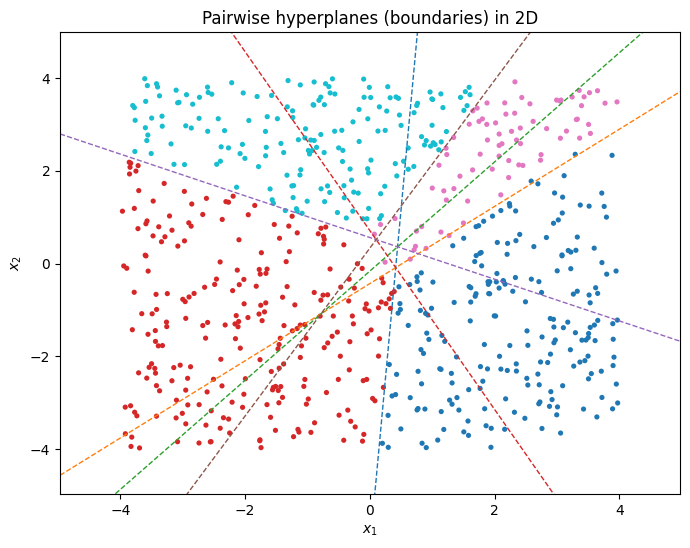

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(11)

N = 700       # объектов
M = 4         # классов
d = 3         # bias + 2 признака

X2 = np.random.uniform(-4, 4, size=(N, 2))
X = np.hstack([np.ones((N, 1)), X2])

W_true = np.random.randn(d, M)

scores_true = X @ W_true
y = np.argmax(scores_true, axis=1)

Y = np.zeros((N, M))
Y[np.arange(N), y] = 1

plt.figure(figsize=(7, 6))
plt.scatter(X2[:, 0], X2[:, 1], c=y, s=18, cmap="tab10")
plt.title("Generated classes (argmax of random hyperplanes)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


def softmax(Z):
    Zs = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Zs)
    return expZ / expZ.sum(axis=1, keepdims=True)

def loss_and_grad(W, X, Y, reg=0.0):
    """
    W: (d, M), X: (N, d), Y: (N, M)
    loss = cross-entropy + L2 (без bias)
    grad = X^T (P - Y)/N + reg*W (без bias)
    """
    Z = X @ W
    P = softmax(Z)

    eps = 1e-12
    N = X.shape[0]
    loss = -np.sum(Y * np.log(P + eps)) / N
    loss += 0.5 * reg * np.sum(W[1:]**2)

    grad = (X.T @ (P - Y)) / N
    grad[1:] += reg * W[1:]
    return loss, grad, P


W = np.zeros((d, M))
lr = 0.4
reg = 1e-3
steps = 2000

losses = []
for t in range(steps):
    L, G, P = loss_and_grad(W, X, Y, reg=reg)
    W -= lr * G
    losses.append(L)

pred = np.argmax(softmax(X @ W), axis=1)
acc = (pred == y).mean()

print(f"Final loss: {losses[-1]:.4f}")
print(f"Train accuracy: {acc:.3f}")

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

grid = np.c_[np.ones(xx.size), xx.ravel(), yy.ravel()]  # bias + coords
grid_pred = np.argmax(softmax(grid @ W), axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, grid_pred, alpha=0.25)

plt.scatter(X2[:, 0], X2[:, 1], c=y, s=15, cmap="tab10", edgecolors="none")
plt.title("Decision regions (trained softmax regression)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(X2[:, 0], X2[:, 1], c=y, s=14, cmap="tab10", edgecolors="none")

xline = np.linspace(x_min, x_max, 400)

for m in range(M):
    for n in range(m + 1, M):
        w = W[:, m] - W[:, n]  # (3,)
        # w0 + w1*x + w2*y = 0 -> y = -(w0 + w1*x)/w2
        if abs(w[2]) < 1e-10:
            if abs(w[1]) > 1e-10:
                x_const = -w[0] / w[1]
                plt.axvline(x_const, linestyle="--", linewidth=1.2)
        else:
            yline = -(w[0] + w[1] * xline) / w[2]
            plt.plot(xline, yline, linestyle="--", linewidth=1.0)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Pairwise hyperplanes (boundaries) in 2D")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

Сначала формируются случайные точки $x_i\in\mathbb R^2$ и добавляется фиктивный признак (bias),
поэтому вектор признаков имеет вид $x=(1,x_1,x_2)^\top$.

Далее задаются случайные веса $W_{\text{true}}\in\mathbb R^{3\times M}$, которые определяют
линейные скоры классов:
$$
s_k(x)=\omega_k^\top x,\qquad k=1,\dots,M.
$$
Метка класса назначается по правилу максимального скора:
$$
y=\arg\max_{k} s_k(x).
$$
Таким образом, классы формируются случайно, но зависят от признаков через неизвестные линейные функции.


### Модель и классификация (softmax-регрессия)

При обучении многоклассовой логистической регрессии для каждого класса вычисляется скор
$$
s_k(x)=\omega_k^\top x,
$$
а затем вероятности через softmax:
$$
p_k(x)=\frac{e^{s_k(x)}}{\sum_{j=1}^M e^{s_j(x)}}.
$$
Классификация выполняется по правилу максимума:
$$
\hat y=\arg\max_k p_k(x)=\arg\max_k s_k(x).
$$


### Гиперплоскости (границы решений)

Граница между классами $m$ и $n$ задаётся равенством скоров:
$$
s_m(x)=s_n(x)
\quad\Longleftrightarrow\quad
(\omega_m-\omega_n)^\top x=0.
$$
Это гиперплоскость в пространстве признаков; в случае двух признаков (2D) она является прямой.
Эти прямые разделяют плоскость на области, внутри которых один класс имеет максимальный скор
(и, следовательно, максимальную вероятность).
